In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

/home/benjamin/anaconda3/lib/python3.11/site-packages/scipy/__init__.py:155: UserWarning: A NumPy version >=1.18.5 and <1.26.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
"""
Start by loading the gribble deltas
"""

'\nStart by loading the gribble deltas\n'

In [19]:
data = pd.read_excel("./FG combined data Feb 2025.xlsx",sheet_name="all CA deltas",nrows=222,usecols="A:M")
data = data.drop('Unnamed: 7', axis=1)


In [20]:
data

,Empty,WT,E179K,K186N,Q204K,L290P,K390N,L566R,L776S,N855S,H1018R,S443C
0,0.001556,0.103533,0.003786,0.002188,0.005176,-0.001588,0.000000,0.009765,0.041375,0.300708,0.007471,0.139895
1,0.001389,0.173933,0.012929,0.000125,0.024824,-0.001235,0.003118,0.053647,0.023125,0.328833,0.090588,0.003000
2,0.003111,0.158867,0.012357,0.037625,0.021765,0.002647,0.002412,0.083059,0.028375,0.253875,0.090059,0.003368
3,-0.002500,0.132467,0.000357,0.054938,0.042294,-0.002176,0.005529,0.066176,0.021625,0.352667,0.005588,0.003421
4,0.000556,0.165667,0.009071,0.002375,0.023529,0.019059,0.002176,0.028529,0.028375,0.210417,0.007706,0.093842
...,...,...,...,...,...,...,...,...,...,...,...,...
217,NaN,NaN,NaN,NaN,NaN,0.019176,NaN,NaN,NaN,NaN,NaN,NaN
218,NaN,NaN,NaN,NaN,NaN,0.022471,NaN,NaN,NaN,NaN,NaN,NaN
219,NaN,NaN,NaN,NaN,NaN,0.031353,NaN,NaN,NaN,NaN,NaN,NaN
220,NaN,NaN,NaN,NaN,NaN,0.043941,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
"""
Plot deltas as heatmap
"""

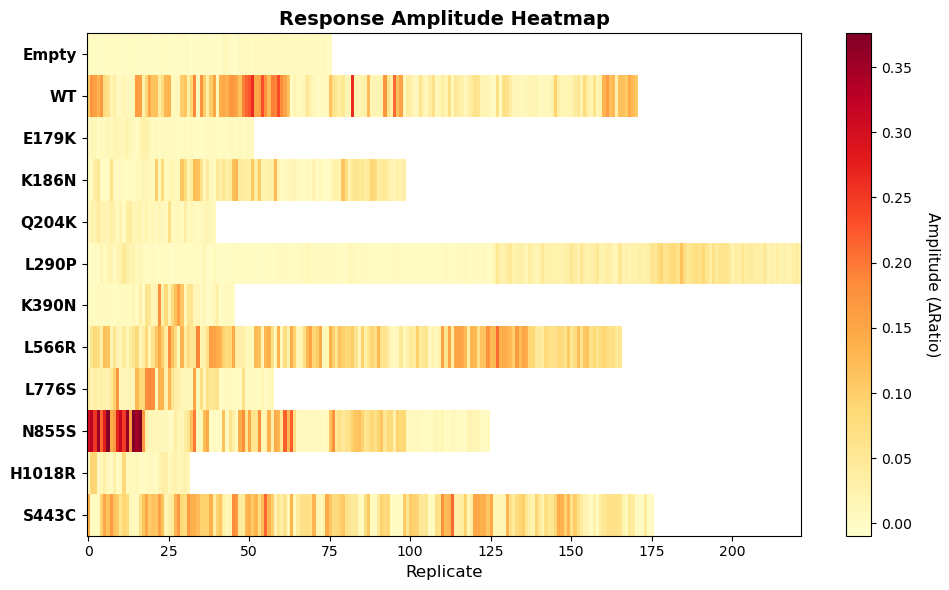

In [29]:
fig3, ax3 = plt.subplots(figsize=(10, 6))

groups = list(data.columns)
max_n = data.count().max()
data_matrix = np.full((len(groups), max_n), np.nan)

for i, group in enumerate(groups):
    values = data[group]
    data_matrix[i, :len(values)] = values

im = ax3.imshow(data_matrix, aspect='auto', cmap='YlOrRd',
                interpolation='nearest')

ax3.set_yticks(np.arange(len(groups)))
ax3.set_yticklabels(groups, fontsize=11, fontweight='bold')
ax3.set_xlabel('Replicate', fontsize=12)
ax3.set_title('Response Amplitude Heatmap', fontsize=14, fontweight='bold')

cbar = plt.colorbar(im, ax=ax3)
cbar.set_label('Amplitude (ΔRatio)', rotation=270, labelpad=20, fontsize=11)

plt.tight_layout()

In [28]:
data.count()

Empty      76
WT        171
E179K      52
K186N      99
Q204K      40
L290P     222
K390N      46
L566R     166
L776S      58
N855S     125
H1018R     32
S443C     176
dtype: int64

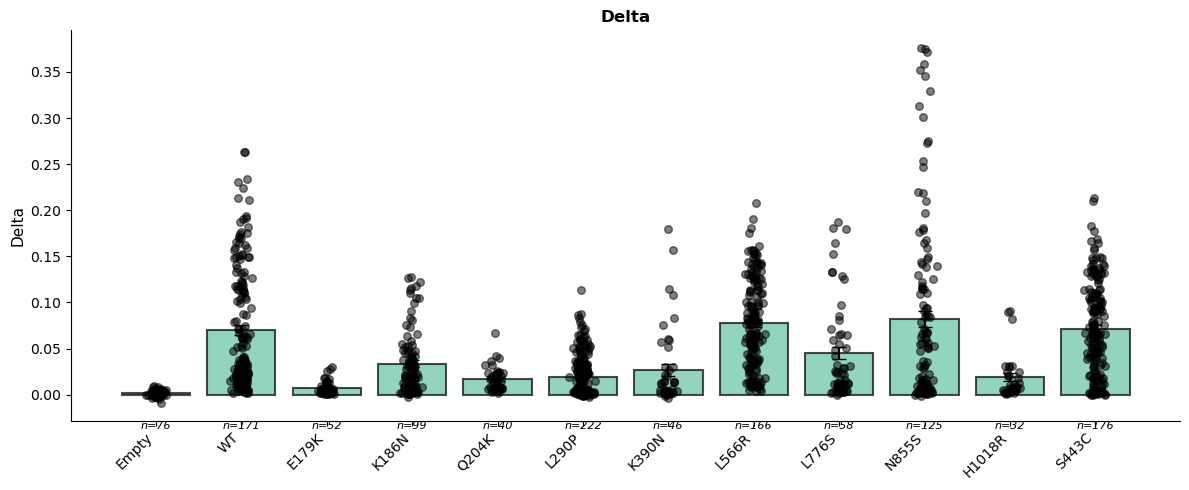

In [62]:
fig2, axes = plt.subplots(figsize=(12, 5))

#for idx, metric in enumerate(['amplitude', 'auc']):
#    ax = axes[idx]

ax = axes
colors = plt.cm.Set2(np.linspace(0, 1, len(data)))

groups = list(data.columns)
means = [np.mean(data[g]) for g in groups]
sems = [stats.sem(data[g],nan_policy='omit') for g in groups]

x_pos = np.arange(len(groups))
bars = ax.bar(x_pos, means, yerr=sems, capsize=5,
             color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)

# Individual points
for i, group in enumerate(groups):
    values = data[group]
    x_jitter = np.random.normal(i, 0.05, size=len(values))
    
    #ax.scatter(x_jitter, values, color='black', alpha=0.5, s=30, zorder=3)

ax.set_xticks(x_pos)
ax.set_xticklabels(groups, rotation=45, ha='right')
ax.set_ylabel("delta".title(), fontsize=11)
ax.set_title(f'{"delta".title()}', fontsize=12, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add sample sizes
for i, group in enumerate(groups):
    n = data[group].count()
    ax.text(i, ax.get_ylim()[0], f'n={n}', ha='center',
           va='top', fontsize=8, style='italic')

plt.tight_layout()

In [43]:
sems

[0.00035998556941518775,
 0.005088087020149351,
 0.0009536729912189624,
 0.0034727931970573943,
 0.002113795518225755,
 0.0014863513065833274,
 0.006207220885321614,
 0.0037260326535228532,
 0.007014322330739476,
 0.009023838495295379,
 0.004326230029570941,
 0.003829594335049582]

In [50]:
groups = list(data.columns)
datap = [data[g].dropna() for g in groups]

# ANOVA
f_stat, p_val = stats.f_oneway(*datap)

# Effect size
grand_mean = np.mean(np.concatenate(datap))
ss_between = sum(len(d) * (np.mean(d) - grand_mean)**2 for d in datap)
ss_total = sum(np.sum((d - grand_mean)**2) for d in datap)
eta_squared = ss_between / ss_total

results = {
    'metric': "delta",
    'F_statistic': f_stat,
    'p_value': p_val,
    'eta_squared': eta_squared,
    'significant': p_val < 0.05
}

# Post-hoc: compare each to WT
if p_val < 0.05 and 'WT' in groups:
    wt_idx = groups.index('WT')
    results['posthoc'] = {}

    for i, group in enumerate(groups):
        if i != wt_idx:
            t_stat, p = stats.ttest_ind(datap[wt_idx], datap[i])
            mean_diff = np.mean(datap[wt_idx]) - np.mean(datap[i])
            pooled_std = np.sqrt((np.var(datap[wt_idx]) + np.var(datap[i])) / 2)
            cohens_d = mean_diff / pooled_std

            results['posthoc'][f'WT vs {group}'] = {
                'p_value': p,
                'mean_diff': mean_diff,
                'cohens_d': cohens_d
            }

In [51]:
results

{'metric': 'delta',
 'F_statistic': 34.275269930253714,
 'p_value': 2.9127920188219065e-64,
 'eta_squared': 0.23158568302144425,
 'significant': True,
 'posthoc': {'WT vs Empty': {'p_value': 9.904780532592491e-17,
   'mean_diff': 0.06831635295216297,
   'cohens_d': 1.454727557463874},
  'WT vs E179K': {'p_value': 1.1555143036192648e-10,
   'mean_diff': 0.06264884507455358,
   'cohens_d': 1.3285333937881707},
  'WT vs K186N': {'p_value': 8.46005821226481e-07,
   'mean_diff': 0.036277104823854024,
   'cohens_d': 0.6866173119067027},
  'WT vs Q204K': {'p_value': 1.26051899232483e-06,
   'mean_diff': 0.05285047547893424,
   'cohens_d': 1.1049762988918592},
  'WT vs L290P': {'p_value': 4.0411183029556616e-23,
   'mean_diff': 0.05044305436296537,
   'cohens_d': 1.0202171648573681},
  'WT vs K390N': {'p_value': 4.201340923861497e-05,
   'mean_diff': 0.04322209339240399,
   'cohens_d': 0.7803997113409027},
  'WT vs L566R': {'p_value': 0.23335462550333178,
   'mean_diff': -0.007564855575676363,

In [56]:
for item in results["posthoc"].keys():
    outcome = results["posthoc"][item]
    if outcome["p_value"]<(0.05/((len(results["posthoc"].keys())**0.5))):
        print(item)
        print(outcome)

WT vs Empty
{'p_value': 9.904780532592491e-17, 'mean_diff': 0.06831635295216297, 'cohens_d': 1.454727557463874}
WT vs E179K
{'p_value': 1.1555143036192648e-10, 'mean_diff': 0.06264884507455358, 'cohens_d': 1.3285333937881707}
WT vs K186N
{'p_value': 8.46005821226481e-07, 'mean_diff': 0.036277104823854024, 'cohens_d': 0.6866173119067027}
WT vs Q204K
{'p_value': 1.26051899232483e-06, 'mean_diff': 0.05285047547893424, 'cohens_d': 1.1049762988918592}
WT vs L290P
{'p_value': 4.0411183029556616e-23, 'mean_diff': 0.05044305436296537, 'cohens_d': 1.0202171648573681}
WT vs K390N
{'p_value': 4.201340923861497e-05, 'mean_diff': 0.04322209339240399, 'cohens_d': 0.7803997113409027}
WT vs L776S
{'p_value': 0.010657007193962426, 'mean_diff': 0.02484558654778707, 'cohens_d': 0.4139348113025058}
WT vs H1018R
{'p_value': 2.9498307757107655e-05, 'mean_diff': 0.051003059220764355, 'cohens_d': 1.0219770129447507}


In [61]:
0.05/len(results["posthoc"].keys())**0.5

0.015075567228888182